# Capstone (DATA 2206)
## Student Placement Risk Prediction Using Machine Learning
#### Developed as a Decision-Support Prototype for the Career Development Cell (CDC)
Prepared By:
Joan Dela Cruz

## Step 0: Imports

In [1]:
# import all needed libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
)

## Step 1: Load data

In [2]:
df = pd.read_csv('student_placement_salary_elite_v2.csv')
df.sample(5)

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
3194,S3194,5.94,Mechanical,2,1,1,1,0,1.8,7.5,48.6,2,6,0,105.6,3,1,Mid-size,Data Scientist,72.37
2842,S2842,7.06,CSE,3,1,1,0,1,86.4,4.9,49.7,1,2,0,64.4,3,1,MNC,Software Engineer,96.05
1329,S1329,6.69,CSE,2,0,0,0,1,9.2,5.6,45.2,0,5,0,49.0,1,1,Startup,Data Scientist,42.74
4336,S4336,7.13,CSE,2,0,0,1,1,81.5,9.3,75.4,3,4,1,96.1,2,1,Mid-size,Analyst,55.58
1470,S1470,9.93,ECE,2,1,1,0,0,38.4,7.5,83.5,1,2,0,65.2,2,1,MNC,Analyst,83.69


## Step 2: EDA

Dataset shape: (9000, 20)
Number of rows: 9000
Number of columns: 20


,count,percent
placed,,
0,1298,14.42
1,7702,85.58


Total missing values: 2596
Duplicate rows: 0


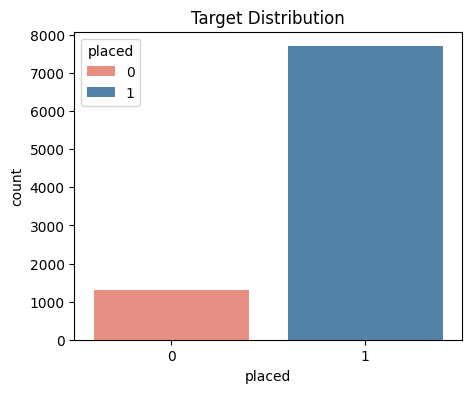

Observation: 'not placed' cases are the minority class, so accuracy alone may be misleading and should not be the primary evaluation metric.


In [3]:
# EDA: dataset shape, target distribution, missing values, duplicate rows, and one simple visual of the target variable.

print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

target_counts = df['placed'].value_counts().sort_index()
target_percent = df['placed'].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent.round(2)
})

display(target_summary)

missing_total = df.isna().sum().sum()
duplicate_rows = df.duplicated().sum()

print("Total missing values:", missing_total)
print("Duplicate rows:", duplicate_rows)

plt.figure(figsize=(5, 4))
sns.countplot(x="placed", hue="placed", data=df, palette={0: "salmon", 1: "steelblue"})
plt.title("Target Distribution")
plt.show()

print(
    "Observation: 'not placed' cases are the minority class, so accuracy alone may be misleading and should not be the primary evaluation metric."
)

In [4]:
# Check data count and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   object 
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   object 
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill_score          9000 non-null   i

In [5]:
# Key Statistics
df.describe()

,cgpa,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,salary_lpa
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,7.507213,2.011778,0.650111,0.555556,0.299778,0.393444,49.783567,6.991267,70.125711,1.032000,3.500556,0.421333,67.785989,1.898889,0.855778,55.409311
std,1.446496,0.818224,0.476961,0.496932,0.458186,0.488541,28.891340,1.717548,17.475032,0.966191,1.707595,0.747207,17.058188,0.953059,0.351334,27.673531
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,40.000000,0.000000,1.000000,0.000000,16.500000,0.000000,0.000000,0.000000
25%,6.257500,1.000000,0.000000,0.000000,0.000000,0.000000,24.900000,5.500000,54.800000,0.000000,2.000000,0.000000,55.900000,1.000000,1.000000,43.427500
50%,7.500000,2.000000,1.000000,1.000000,0.000000,0.000000,49.600000,7.000000,70.300000,1.000000,4.000000,0.000000,67.400000,2.000000,1.000000,60.100000
75%,8.750000,3.000000,1.000000,1.000000,1.000000,1.000000,74.625000,8.500000,85.400000,2.000000,5.000000,1.000000,79.000000,3.000000,1.000000,75.380000
max,10.000000,3.000000,1.000000,1.000000,1.000000,1.000000,100.000000,10.000000,100.000000,3.000000,6.000000,3.000000,132.100000,4.000000,1.000000,129.430000


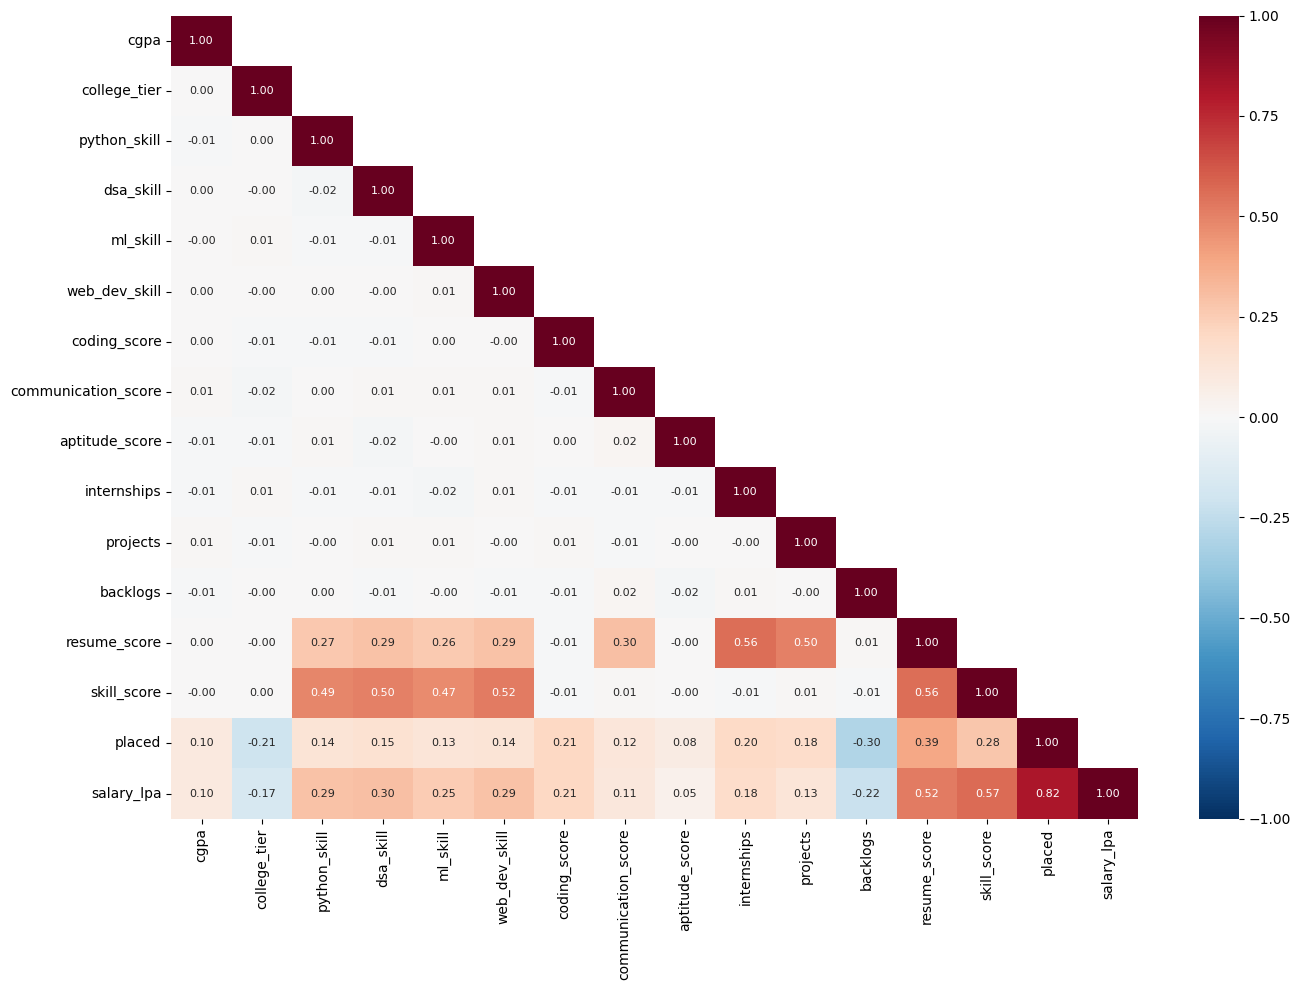

In [6]:
# Correlation heatmap to see which variables are most related to 'placed'

plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True).round(2)

# Hide the upper-right half of heatmap
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, 
            vmin=-1,
            vmax=1,
            mask=mask,
            annot=True, 
            cmap="RdBu_r",
            fmt=".2f",
            annot_kws={"size": 8}
)
plt.tight_layout()
plt.show()

## Step 3: Create the modeling target

In [7]:
# Create a derived target for modeling:
df["at_risk"] = 1 - df["placed"]
df.head()

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,...,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa,at_risk
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,...,1,3,0,62.6,2,1,MNC,Software Engineer,63.55,0
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,...,1,6,0,77.5,2,1,MNC,Data Scientist,75.17,0
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,...,0,5,1,76.0,3,1,MNC,Software Engineer,80.44,0
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,...,0,6,0,74.3,2,1,MNC,Software Engineer,72.11,0
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,...,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05,0


* placed = 1 means the student received a job offer
* placed = 0 means the student did not receive a job offer
* at_risk = 1 means not placed
* at_risk = 0 means placed

This makes recall, precision, class weighting, and dashboard language easier to understand.

## Step 4: Remove leakage columns
Reasons:

- `student_id` is an identifier.
- `placed` is the original target.
- `at_risk` is the derived target.
- `company_type`, `job_role`, and `salary_lpa` are post-placement outcome variables and would cause target leakage.
- `skill_score` is a direct sum of: python_skill + dsa_skill + ml_skill + web_dev_skill; it double-counts the same information.

In [8]:
removed_cols = [
    "student_id",
    "placed",
    "at_risk",
    "company_type",
    "job_role",
    "salary_lpa",
    "skill_score",
]

# Define independent variables
X = df.drop(columns=removed_cols)

# Define target variable
y = df["at_risk"]

In [9]:
# Check final features:
X.columns

Index(['cgpa', 'branch', 'college_tier', 'python_skill', 'dsa_skill',
       'ml_skill', 'web_dev_skill', 'coding_score', 'communication_score',
       'aptitude_score', 'internships', 'projects', 'backlogs',
       'resume_score'],
      dtype='object')

## Step 5: Define feature groups

In [10]:
numeric_features = [
    "cgpa",
    "coding_score",
    "communication_score",
    "aptitude_score",
    "internships",
    "projects",
    "backlogs",
    "resume_score",
]

binary_features = [
    "python_skill",
    "dsa_skill",
    "ml_skill",
    "web_dev_skill",
]

nominal_features = [
    "branch",
]

ordinal_features = [
    "college_tier",
]

## Step 6: Create train-validation-test split

In [11]:
# First split: create final test set.
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Split X_train again into X_train_main and X_valid
* X_train_main, y_train_main -> model training and hyperparameter tuning
* X_valid, y_valid           -> model comparison and threshold tuning
* X_test, y_test             -> final evaluation only

In [12]:
# Second split: validation set from training data
X_train_main, X_valid, y_train_main, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [13]:
# Check the sizes:
print("X_train_main:", X_train_main.shape)
print("X_valid:", X_valid.shape)
print("X_test:", X_test.shape)

X_train_main: (5760, 14)
X_valid: (1440, 14)
X_test: (1800, 14)


In [14]:
# Check class balance:
print("Train main:")
print(y_train_main.value_counts(normalize=True))

print("Validation:")
print(y_valid.value_counts(normalize=True))

print("Test:")
print(y_test.value_counts(normalize=True))

Train main:
at_risk
0    0.855903
1    0.144097
Name: proportion, dtype: float64
Validation:
at_risk
0    0.855556
1    0.144444
Name: proportion, dtype: float64
Test:
at_risk
0    0.855556
1    0.144444
Name: proportion, dtype: float64


## Step 7: Build preprocessing pipelines

#### Logistic Regression should use:
- Standard scaling for numeric features.
- One-hot encoding for `branch`.
- Ordinal encoding for `college_tier`.

In [15]:
college_tier_order = [[1, 2, 3]]

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("bin", "passthrough", binary_features),
        ("branch", OneHotEncoder(handle_unknown="ignore"), nominal_features),
        ("tier", OrdinalEncoder(categories=college_tier_order), ordinal_features),
    ]
)

#### Tree-model preprocessing
Random Forest and XGBoost do not require scaling.

In [16]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("bin", "passthrough", binary_features),
        ("branch", OneHotEncoder(handle_unknown="ignore"), nominal_features),
        ("tier", OrdinalEncoder(categories=college_tier_order), ordinal_features),
    ]
)

## Step 8: Create baseline models
##### 1. Logistic Regression baseline

In [19]:
logistic_model = Pipeline(
    steps=[
        ("preprocess", logistic_preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=100
        ))
    ]
)

##### 2. Random Forest baseline

In [20]:
rf_model = Pipeline(
    steps=[
        ("preprocess", tree_preprocessor),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            random_state=100,
            n_jobs=-1
        ))
    ]
)

##### 3. XGBoost baseline

In [22]:
# Because `at_risk = 1` is the positive class

scale_pos_weight = (y_train_main == 0).sum() / (y_train_main == 1).sum()
# scale_pos_weight

xgb_model = Pipeline(
    steps=[
        ("preprocess", tree_preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=100,
            n_jobs=-1
        ))
    ]
)

## Step 9: Define evaluation helper function
This function evaluates a model using predicted probabilities and a threshold.
Default threshold is `0.50`.

In [23]:
def evaluate_model(model, X_data, y_true, threshold=0.50, model_name="Model"):
    proba = model.predict_proba(X_data)[:, 1]
    preds = (proba >= threshold).astype(int)

    print("=" * 80)
    print(model_name)
    print("Threshold:", threshold)
    print()

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, preds))
    print()

    print("Classification Report:")
    print(classification_report(
        y_true,
        preds,
        target_names=["not_at_risk", "at_risk"],
        zero_division=0
    ))

    print("Balanced Accuracy:", balanced_accuracy_score(y_true, preds))
    print("ROC-AUC:", roc_auc_score(y_true, proba))
    print("PR-AUC:", average_precision_score(y_true, proba))

## Step 10: Train and evaluate baseline models on validation set
* Fit baseline models using only `X_train_main, y_train_main`.
* Evaluate them on `X_valid, y_valid`.

In [24]:
baseline_models = {
    "Logistic Regression Baseline": logistic_model,
    "Random Forest Baseline": rf_model,
    "XGBoost Baseline": xgb_model,
}

for name, model in baseline_models.items():
    # print("=" * 80)
    # print(name)
    model.fit(X_train_main, y_train_main)
    evaluate_model(model, X_valid, y_valid, threshold=0.50, model_name=name)

Logistic Regression Baseline
Threshold: 0.5

Confusion Matrix:
[[1091  141]
 [  19  189]]

Classification Report:
              precision    recall  f1-score   support

 not_at_risk       0.98      0.89      0.93      1232
     at_risk       0.57      0.91      0.70       208

    accuracy                           0.89      1440
   macro avg       0.78      0.90      0.82      1440
weighted avg       0.92      0.89      0.90      1440

Balanced Accuracy: 0.8971028971028971
ROC-AUC: 0.9633101273726274
PR-AUC: 0.8168402231108512
Random Forest Baseline
Threshold: 0.5

Confusion Matrix:
[[1212   20]
 [ 116   92]]

Classification Report:
              precision    recall  f1-score   support

 not_at_risk       0.91      0.98      0.95      1232
     at_risk       0.82      0.44      0.57       208

    accuracy                           0.91      1440
   macro avg       0.87      0.71      0.76      1440
weighted avg       0.90      0.91      0.89      1440

Balanced Accuracy: 0.7130369630

For final reporting, we prioritize:

1. Recall for `at_risk = 1`
2. Precision for `at_risk = 1`
3. F1-score for `at_risk = 1`
4. PR-AUC
5. Balanced accuracy
6. Calibration/Brier score if using probability bands
7. Overall accuracy only as a secondary metric

## Step 11: Hyperparameter tuning
Tune the models using `RandomizedSearchCV`.
Use `X_train_main, y_train_main`.

In [35]:
from sklearn.model_selection import StratifiedKFold
# Create the cross-validation strategy:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

# use multiple metrics:
scoring = {
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "average_precision": "average_precision"
}

# cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=100)

### 11A: Tune Logistic Regression

In [37]:
from sklearn.model_selection import GridSearchCV

# Define possible Logistic Regression settings:
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__penalty": ['l2'],
}

# Run the randomized search:
# logistic_search = RandomizedSearchCV(
logistic_search = GridSearchCV(
    estimator=logistic_model,
    # param_distributions=logistic_param_grid,
    param_grid=logistic_param_grid,
    # n_iter=8,
    scoring=scoring,
    refit="recall",
    cv=cv,
    # random_state=100,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Train and print best results after the randomized search:
logistic_search.fit(X_train_main, y_train_main)

print("Best Logistic Regression parameters:")
print(logistic_search.best_params_)
print("Best cross-validation recall:")
print(logistic_search.best_score_)

# Save the best model:
best_logistic = logistic_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression parameters:
{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best cross-validation recall:
0.9518072289156626


#### Evaluate tuned Logistic Regression on validation set:

In [38]:
evaluate_model(
    best_logistic,
    X_valid,
    y_valid,
    threshold=0.50,
    model_name="Tuned Logistic Regression"
)

Tuned Logistic Regression
Threshold: 0.5

Confusion Matrix:
[[1053  179]
 [  12  196]]

Classification Report:
              precision    recall  f1-score   support

 not_at_risk       0.99      0.85      0.92      1232
     at_risk       0.52      0.94      0.67       208

    accuracy                           0.87      1440
   macro avg       0.76      0.90      0.79      1440
weighted avg       0.92      0.87      0.88      1440

Balanced Accuracy: 0.8985077422577423
ROC-AUC: 0.9587404782717283
PR-AUC: 0.8027461194485337


### 11B: Tune Random Forest

In [39]:
# Define possible Random Forest settings:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion":['gini','entropy'],
    "model__bootstrap": [True, False],
}

# Run the randomized search:
# rf_search = RandomizedSearchCV(
#     estimator=rf_model,
#     param_distributions=rf_param_grid,
#     n_iter=20,
#     scoring="recall",
#     cv=cv,
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )
rf_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    # n_iter=20,
    # scoring="recall",
    scoring=scoring,
    refit="recall",
    cv=cv,
    # random_state=100,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Train and print best results after the randomized search:
rf_search.fit(X_train_main, y_train_main)

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print("Best CV recall:")
print(rf_search.best_score_)

# Save the best model:
best_rf = rf_search.best_estimator_

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best Random Forest parameters:
{'model__bootstrap': False, 'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV recall:
0.9108433734939758


#### Evaluate tuned Random Forest on validation set:

In [40]:
evaluate_model(
    best_rf,
    X_valid,
    y_valid,
    threshold=0.50,
    model_name="Tuned Random Forest"
)

Tuned Random Forest
Threshold: 0.5

Confusion Matrix:
[[983 249]
 [ 20 188]]

Classification Report:
              precision    recall  f1-score   support

 not_at_risk       0.98      0.80      0.88      1232
     at_risk       0.43      0.90      0.58       208

    accuracy                           0.81      1440
   macro avg       0.71      0.85      0.73      1440
weighted avg       0.90      0.81      0.84      1440

Balanced Accuracy: 0.8508678821178821
ROC-AUC: 0.9331020541958044
PR-AUC: 0.7261717624542855


#### 11C: Tune XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define possible XGBoost settings:
xgb_param_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [2, 4],
    "model__learning_rate": [0.03, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 5],
    "model__gamma": [0, 0.1, 0.5, 1],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 2, 5, 10],
    "model__scale_pos_weight": [
        scale_pos_weight,
        scale_pos_weight * 1.25,
        scale_pos_weight * 1.5,
    ],
}

# Run the randomized search:
xgb_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    # param_distributions=xgb_param_grid,
    # n_iter=50,
    # scoring="recall",
    scoring=scoring,
    refit="recall",
    cv=cv,
    # random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Train and print best results after the randomized search:
xgb_search.fit(X_train_main, y_train_main)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)
print("Best CV recall:")
print(xgb_search.best_score_)

# Save the best model:
best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 12288 candidates, totalling 61440 fits
Best XGBoost parameters:
{'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__min_child_weight': 1, 'model__n_estimators': 200, 'model__reg_alpha': 0.1, 'model__reg_lambda': 2, 'model__scale_pos_weight': np.float64(8.909638554216867), 'model__subsample': 1.0}
Best CV recall:
0.9602409638554217


#### Evaluate tuned XGBoost on validation set:

In [34]:
evaluate_model(
    best_xgb,
    X_valid,
    y_valid,
    threshold=0.50,
    model_name="Tuned XGBoost"
)

Tuned XGBoost
Threshold: 0.5

Confusion Matrix:
[[960 272]
 [ 12 196]]

Classification Report:
              precision    recall  f1-score   support

 not_at_risk       0.99      0.78      0.87      1232
     at_risk       0.42      0.94      0.58       208

    accuracy                           0.80      1440
   macro avg       0.70      0.86      0.73      1440
weighted avg       0.91      0.80      0.83      1440

Balanced Accuracy: 0.8607642357642358
ROC-AUC: 0.9389106986763237
PR-AUC: 0.7212275041295104


### 11D: Learning curve analysis

In [99]:
#Define Plot for learning curve

from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, model_name, scoring="recall"):
    train_sizes, train_scores, valid_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training score")
    plt.plot(train_sizes, valid_mean, marker="o", label="Cross-validation score")

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15
    )

    plt.fill_between(
        train_sizes,
        valid_mean - valid_std,
        valid_mean + valid_std,
        alpha=0.15
    )

    plt.title(f"Learning Curve: {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

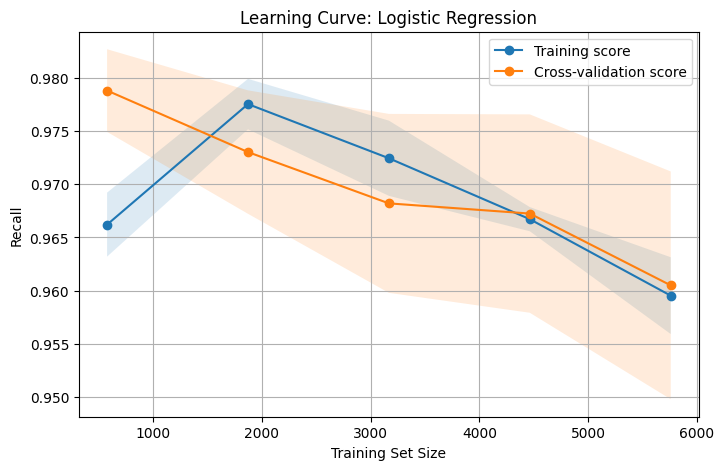

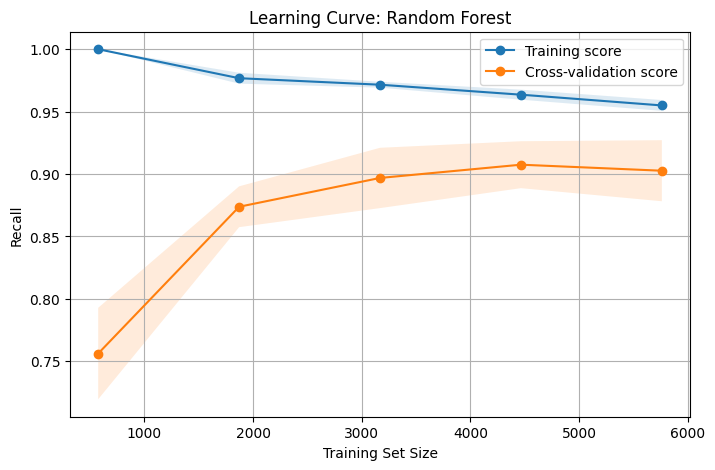

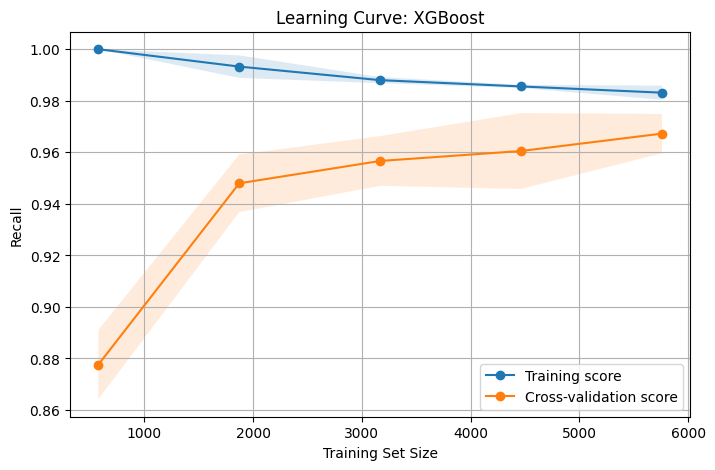

In [100]:
#Plot Learning Curve
plot_learning_curve(best_logistic, X_train, y_train, "Logistic Regression", scoring="recall")
plot_learning_curve(best_rf, X_train, y_train, "Random Forest", scoring="recall")
plot_learning_curve(best_xgb, X_train, y_train, "XGBoost", scoring="recall")

* The learning curves show that Logistic Regression had the most stable generalization pattern, with training and cross-validation recall closely aligned across training sizes.
* Random Forest and XGBoost showed larger gaps between training and validation recall, suggesting some overfitting, although both models improved as more training data became available.
* XGBoost achieved strong validation recall at larger training sizes, but Logistic Regression remained the most consistent and interpretable model for the project’s recall-focused objective

## Step 12: Compare tuned models on validation set
Use `X_valid, y_valid` to compare the tuned models.

In [101]:
def get_validation_metrics(model, X_data, y_true, threshold=0.50):
    proba = model.predict_proba(X_data)[:, 1]
    preds = (proba >= threshold).astype(int)

    return {
        "precision_at_risk": precision_score(y_true, preds, zero_division=0),
        "recall_at_risk": recall_score(y_true, preds, zero_division=0),
        "f1_at_risk": f1_score(y_true, preds, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, preds),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }

# Create comparison table:
tuned_models = {
    "Logistic Regression": best_logistic,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
}

validation_results = []

for name, model in tuned_models.items():
    metrics = get_validation_metrics(model, X_valid, y_valid, threshold=0.50)
    metrics["model"] = name
    validation_results.append(metrics)

validation_results_df = pd.DataFrame(validation_results)
validation_results_df = validation_results_df[
    [
        "model",
        "recall_at_risk",
        "precision_at_risk",
        "f1_at_risk",
        "balanced_accuracy",
        "pr_auc",
        "roc_auc",
    ]
]

validation_results_df.sort_values(
    by=["recall_at_risk", "f1_at_risk", "precision_at_risk"],
    ascending=False
)

,model,recall_at_risk,precision_at_risk,f1_at_risk,balanced_accuracy,pr_auc,roc_auc
0,Logistic Regression,0.942308,0.522667,0.672384,0.898508,0.802746,0.958740
2,XGBoost,0.937500,0.436242,0.595420,0.866477,0.750129,0.945496
1,Random Forest,0.889423,0.446860,0.594855,0.851773,0.723804,0.932540


Select a candidate model based on:
1. Recall for at_risk
2. Precision for at_risk
3. F1-score for at_risk
4. PR-AUC
5. Interpretability

In [102]:
candidate_model = best_logistic
candidate_model_name = "Logistic Regression"

## Step 13: Tune classification threshold on validation set
* use validation data only
* choose a threshold that gives good recall/precision balance

In [103]:
def threshold_table(model, X_data, y_true):
    proba = model.predict_proba(X_data)[:, 1]
    rows = []

    for threshold in np.arange(0.05, 0.96, 0.05):
        preds = (proba >= threshold).astype(int)

        rows.append({
            "threshold": round(threshold, 2),
            "precision_at_risk": precision_score(y_true, preds, zero_division=0),
            "recall_at_risk": recall_score(y_true, preds, zero_division=0),
            "f1_at_risk": f1_score(y_true, preds, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true, preds),
            "predicted_at_risk_count": int(preds.sum()),
        })

    return pd.DataFrame(rows)

In [104]:
# Run threshold tuning for best candidate model:
threshold_results = threshold_table(candidate_model, X_valid, y_valid)
threshold_results

,threshold,precision_at_risk,recall_at_risk,f1_at_risk,balanced_accuracy,predicted_at_risk_count
0,0.05,0.197156,1.000000,0.329375,0.656250,1055
1,0.10,0.230855,1.000000,0.375113,0.718750,901
2,0.15,0.269430,1.000000,0.424490,0.771104,772
3,0.20,0.302766,1.000000,0.464804,0.805601,687
4,0.25,0.335484,1.000000,0.502415,0.832792,620
5,0.30,0.368794,1.000000,0.538860,0.855519,564
6,0.35,0.400000,1.000000,0.571429,0.873377,520
7,0.40,0.448802,0.990385,0.617691,0.892514,459
8,0.45,0.484412,0.971154,0.646400,0.898320,417
9,0.50,0.522667,0.942308,0.672384,0.898508,375


In [105]:
# Filter for the recall target:
threshold_results[threshold_results["recall_at_risk"] >= 0.80].sort_values(
    by=["f1_at_risk", "precision_at_risk"],
    ascending=False
)

,threshold,precision_at_risk,recall_at_risk,f1_at_risk,balanced_accuracy,predicted_at_risk_count
10,0.55,0.564706,0.923077,0.700730,0.901474,340
11,0.60,0.582237,0.850962,0.691406,0.873939,304
9,0.50,0.522667,0.942308,0.672384,0.898508,375
8,0.45,0.484412,0.971154,0.646400,0.898320,417
7,0.40,0.448802,0.990385,0.617691,0.892514,459
6,0.35,0.400000,1.000000,0.571429,0.873377,520
5,0.30,0.368794,1.000000,0.538860,0.855519,564
4,0.25,0.335484,1.000000,0.502415,0.832792,620
3,0.20,0.302766,1.000000,0.464804,0.805601,687
2,0.15,0.269430,1.000000,0.424490,0.771104,772


## Step 14 — Final Threshold Selection

In [106]:
# Choose a threshold.
selected_threshold = 0.55

# Evaluate candidate model on validation set using chosen threshold:
evaluate_model(
    candidate_model,
    X_valid,
    y_valid,
    threshold=selected_threshold,
    model_name=f"{candidate_model_name} with Tuned Threshold"
)

Logistic Regression with Tuned Threshold
Threshold: 0.55

Confusion Matrix:
[[1084  148]
 [  16  192]]

Classification Report:
              precision    recall  f1-score   support

 not_at_risk       0.99      0.88      0.93      1232
     at_risk       0.56      0.92      0.70       208

    accuracy                           0.89      1440
   macro avg       0.78      0.90      0.82      1440
weighted avg       0.92      0.89      0.90      1440

Balanced Accuracy: 0.9014735264735265
ROC-AUC: 0.9587404782717283
PR-AUC: 0.8027461194485337


## Step 15: Final evaluation on test set
Use `X_test, y_test`

In [107]:
evaluate_model(
    candidate_model,
    X_test,
    y_test,
    threshold=selected_threshold,
    model_name=f"Final Test Evaluation: {candidate_model_name}"
)

Final Test Evaluation: Logistic Regression
Threshold: 0.55

Confusion Matrix:
[[1332  208]
 [  24  236]]

Classification Report:
              precision    recall  f1-score   support

 not_at_risk       0.98      0.86      0.92      1540
     at_risk       0.53      0.91      0.67       260

    accuracy                           0.87      1800
   macro avg       0.76      0.89      0.80      1800
weighted avg       0.92      0.87      0.88      1800

Balanced Accuracy: 0.8863136863136862
ROC-AUC: 0.9581393606393607
PR-AUC: 0.8086912939634441


## Step 16: SHAP Model Explainability

SHAP explains the predicted probability/model score.
The threshold 0.55 converts that probability into the final class label.

In [108]:
candidate_model = best_logistic
candidate_model_name = "Logistic Regression"
selected_threshold = 0.55

#### Step 1: Extract the preprocessor and Logistic Regression model

In [ ]:
# Logistic Regression model is inside a scikit-learn pipeline
preprocessor = candidate_model.named_steps["preprocess"]
final_estimator = candidate_model.named_steps["model"]

# Check:
# preprocessor
final_estimator

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


#### Step 2: Transform training and test data

SHAP cannot explain the raw `X_test` directly because the model was trained after preprocessing.
Data needs to be transformed first.

In [110]:
# transform data first
X_train_transformed = preprocessor.transform(X_train_main)
X_test_transformed = preprocessor.transform(X_test)

In [111]:
# If the transformed data is sparse, convert it:
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

#### Step 3: Get transformed feature names
Because the pipeline uses scaling and one-hot encoding, the final model sees transformed feature names.

In [112]:
feature_names = preprocessor.get_feature_names_out()

clean_feature_names = [
    name.split("__", 1)[1] if "__" in name else name
    for name in feature_names
]

clean_feature_names

['cgpa',
 'coding_score',
 'communication_score',
 'aptitude_score',
 'internships',
 'projects',
 'backlogs',
 'resume_score',
 'python_skill',
 'dsa_skill',
 'ml_skill',
 'web_dev_skill',
 'branch_CSE',
 'branch_Civil',
 'branch_ECE',
 'branch_EEE',
 'branch_IT',
 'branch_Mechanical',
 'college_tier']

#### Step 4: Create transformed DataFrames

In [113]:
X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=clean_feature_names,
    index=X_train_main.index
)

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=clean_feature_names,
    index=X_test.index
)

X_test_transformed_df.head()

,cgpa,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,python_skill,dsa_skill,ml_skill,web_dev_skill,branch_CSE,branch_Civil,branch_ECE,branch_EEE,branch_IT,branch_Mechanical,college_tier
4806,-0.211475,-0.419585,-0.655190,0.034811,-0.021711,-1.462286,0.778908,-0.737444,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7501,1.421211,-1.722378,-0.185340,-0.956588,1.020438,1.461068,-0.559150,2.023307,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4765,-1.389488,0.508003,-1.066309,1.162955,1.020438,0.876397,-0.559150,1.263953,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5172,-0.128807,1.452962,0.401973,0.906559,-0.021711,-1.462286,-0.559150,0.074888,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0
8046,1.290321,-0.575921,-1.301234,0.416557,-1.063861,-1.462286,-0.559150,-0.914038,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


#### Step 5: Create SHAP explainer for Logistic Regression
Because the final model is Logistic Regression, use `shap.LinearExplainer`.

In [114]:
import shap

explainer = shap.LinearExplainer(
    final_estimator,
    X_train_transformed_df
)

shap_values = explainer.shap_values(X_test_transformed_df)

In [115]:
# For your binary Logistic Regression model, `shap_values` should represent contributions toward the 
# positive class: at_risk = 1

shap_values_for_at_risk = shap_values

# Check the shape: The two shapes should match.
print(shap_values_for_at_risk.shape)
print(X_test_transformed_df.shape)

(1800, 19)
(1800, 19)


#### Step 6: Create global SHAP bar plot
The SHAP bar plot ranks features by their average absolute contribution to the model's predictions.

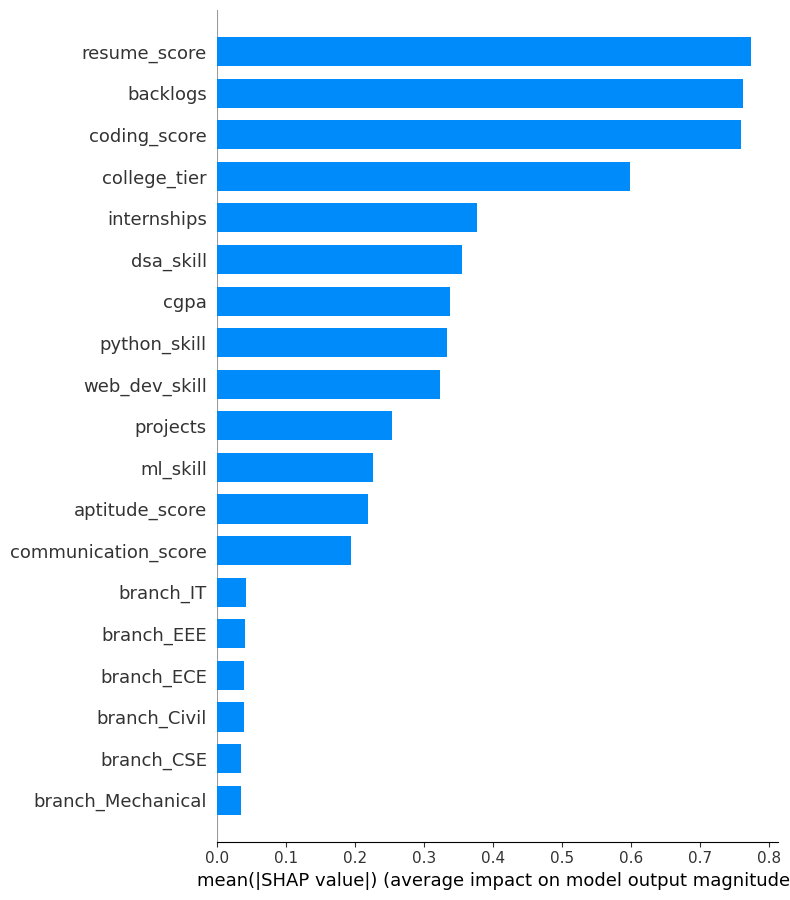

In [116]:
shap.summary_plot(
    shap_values_for_at_risk,
    X_test_transformed_df,
    feature_names=clean_feature_names,
    plot_type="bar"
)